# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

**Nombre:** José Armando Sarango Cuenca

## Paso 0 — Preparación del entorno

In [ ]:
!pip -q install transformers
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from sklearn.decomposition import PCA

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

Dispositivo: cuda


## Paso 1 — Obtener embeddings de imágenes y textos con CLIP

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

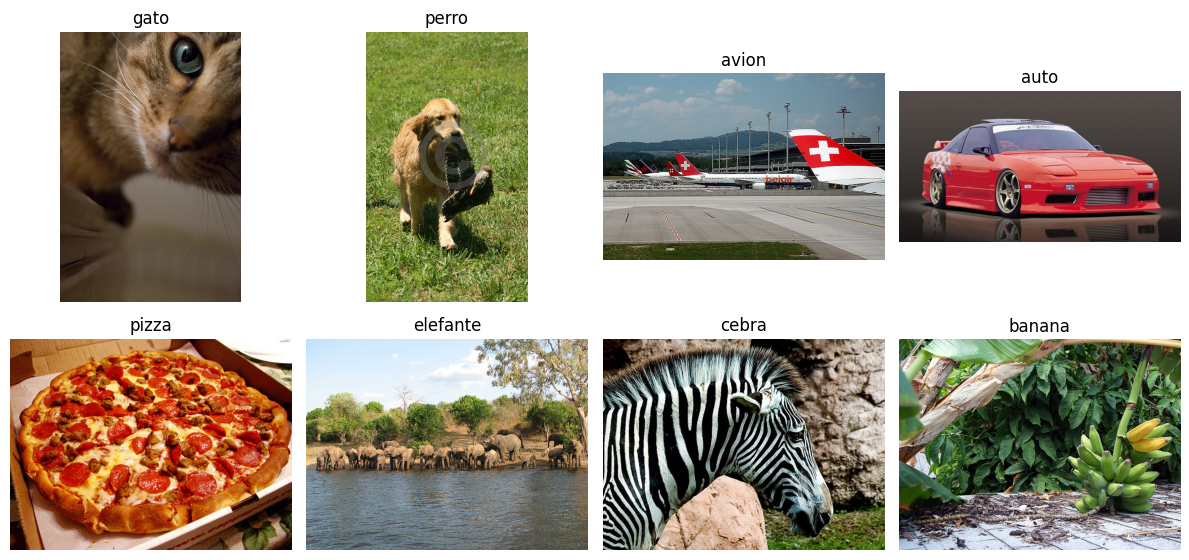

In [2]:
# cargar el modelo y el procesador
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

#  imágenes de ejemplo
BASE = "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master"
image_urls = {
    "gato":     f"{BASE}/n02123045_tabby.JPEG",
    "perro":    f"{BASE}/n02099601_golden_retriever.JPEG",
    "avion":    f"{BASE}/n02690373_airliner.JPEG",
    "auto":     f"{BASE}/n04285008_sports_car.JPEG",
    "pizza":    f"{BASE}/n07873807_pizza.JPEG",
    "elefante": f"{BASE}/n02504458_African_elephant.JPEG",
    "cebra":    f"{BASE}/n02391049_zebra.JPEG",
    "banana":   f"{BASE}/n07753592_banana.JPEG",
}

# Descripción en inglés que le pasamos a CLIP (una por imagen, en el mismo orden)
captions = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of an airplane",
    "a photo of a car",
    "a photo of a pizza",
    "a photo of an elephant",
    "a photo of a zebra",
    "a photo of a banana",
]

labels = list(image_urls.keys())
images = [Image.open(BytesIO(requests.get(u).content)).convert("RGB")
          for u in image_urls.values()]

# Vista rápida de las imágenes cargadas
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.ravel(), images, labels):
    ax.imshow(img); ax.set_title(lbl); ax.axis("off")
plt.tight_layout(); plt.show()

In [3]:
#Calcular los embeddings de imágenes y de textos
with torch.no_grad():
    img_inputs = processor(images=images, return_tensors="pt").to(device)
    image_embeds = model.get_image_features(**img_inputs).pooler_output

    txt_inputs = processor(text=captions, return_tensors="pt", padding=True).to(device)
    text_embeds = model.get_text_features(**txt_inputs).pooler_output

# Normalizamos a longitud 1
image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds  = text_embeds  / text_embeds.norm(dim=-1, keepdim=True)

image_embeds = image_embeds.cpu().numpy()
text_embeds  = text_embeds.cpu().numpy()
print("Embeddings calculados ")

Embeddings calculados 


## Paso 2 — Verificar que ambos viven en el mismo espacio

In [4]:
# Confirmar que imágenes y textos comparten el mismo espacio vectorial
print("Shape embeddings de imágenes:", image_embeds.shape)
print("Shape embeddings de textos:  ", text_embeds.shape)
print("¿Misma dimensión?", image_embeds.shape[1] == text_embeds.shape[1])

# Ejemplo
sim_gato = float(np.dot(image_embeds[0], text_embeds[0]))
print(f"\nSimilitud (imagen gato ↔ texto 'a photo of a cat'): {sim_gato:.3f}")

Shape embeddings de imágenes: (8, 512)
Shape embeddings de textos:   (8, 512)
¿Misma dimensión? True

Similitud (imagen gato ↔ texto 'a photo of a cat'): 0.278


## Paso 3 — Proyectar los vectores a 2D y graficarlos

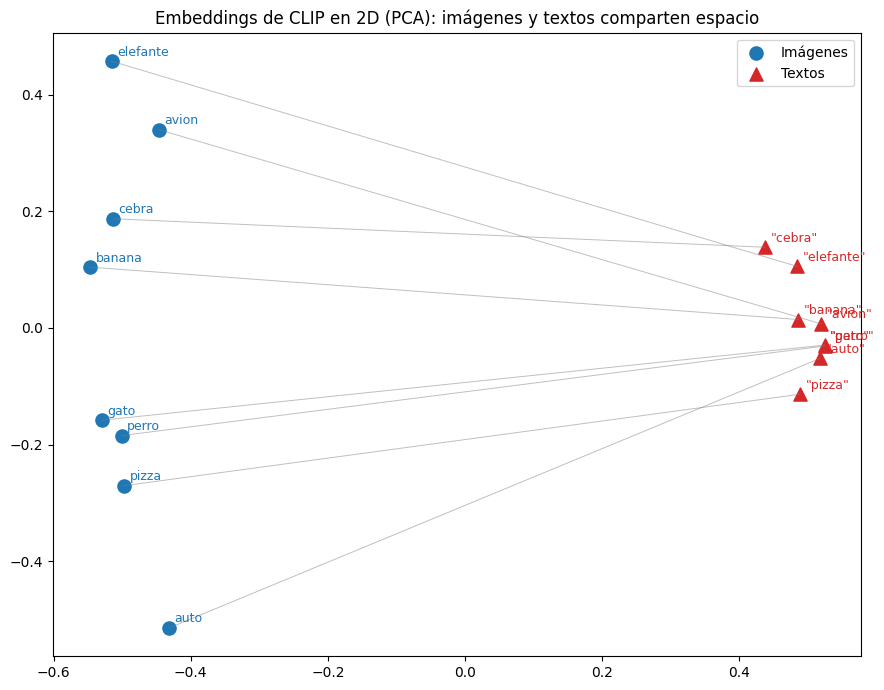

In [5]:
# Reducir a 2D con PCA y graficar imágenes + textos juntos
all_embeds = np.vstack([image_embeds, text_embeds])
coords = PCA(n_components=2, random_state=42).fit_transform(all_embeds)

img_xy = coords[:len(labels)]
txt_xy = coords[len(labels):]

plt.figure(figsize=(9, 7))
plt.scatter(img_xy[:, 0], img_xy[:, 1], c="tab:blue",   marker="o", s=90, label="Imágenes")
plt.scatter(txt_xy[:, 0], txt_xy[:, 1], c="tab:red", marker="^", s=90, label="Textos")

for i, lbl in enumerate(labels):
    plt.annotate(lbl,           img_xy[i], fontsize=9, color="tab:blue",
                 xytext=(4, 4), textcoords="offset points")
    plt.annotate(f'"{lbl}"',    txt_xy[i], fontsize=9, color="tab:red",
                 xytext=(4, 4), textcoords="offset points")
    plt.plot([img_xy[i, 0], txt_xy[i, 0]],
             [img_xy[i, 1], txt_xy[i, 1]], "gray", lw=0.7, alpha=0.5)

plt.title("Embeddings de CLIP en 2D (PCA): imágenes y textos comparten espacio")
plt.legend(); plt.tight_layout(); plt.show()

## Paso 4 — Verificar emparejamientos con cosine similarity

In [9]:
#matriz de similitud coseno (filas=imágenes, columnas=textos)
sims = image_embeds @ text_embeds.T

# Búsqueda imagen -> texto
print(" IMAGEN → TEXTO")
for i, lbl in enumerate(labels):
    j = sims[i].argmax()
    ok = "Si" if j == i else "No"
    print(f"  Imagen '{lbl}'  ->  \"{captions[j]}\"  (sim={sims[i, j]:.3f}) {ok}")

# Búsqueda texto -> imagen
print("\n TEXTO → IMAGEN")
for j, cap in enumerate(captions):
    i = sims[:, j].argmax()
    ok = "si" if i == j else "no"
    print(f'  "{cap}"  ->  imagen \'{labels[i]}\'  (sim={sims[i, j]:.3f}) {ok}')

acc = np.mean(sims.argmax(axis=1) == np.arange(len(labels)))
print(f"\nExactitud del emparejamiento imagen→texto: {acc:.0%}")

 IMAGEN → TEXTO
  Imagen 'gato'  ->  "a photo of a cat"  (sim=0.278) Si
  Imagen 'perro'  ->  "a photo of a dog"  (sim=0.284) Si
  Imagen 'avion'  ->  "a photo of an airplane"  (sim=0.227) Si
  Imagen 'auto'  ->  "a photo of a car"  (sim=0.241) Si
  Imagen 'pizza'  ->  "a photo of a pizza"  (sim=0.297) Si
  Imagen 'elefante'  ->  "a photo of an elephant"  (sim=0.280) Si
  Imagen 'cebra'  ->  "a photo of a zebra"  (sim=0.337) Si
  Imagen 'banana'  ->  "a photo of a banana"  (sim=0.254) Si

 TEXTO → IMAGEN
  "a photo of a cat"  ->  imagen 'gato'  (sim=0.278) si
  "a photo of a dog"  ->  imagen 'perro'  (sim=0.284) si
  "a photo of an airplane"  ->  imagen 'avion'  (sim=0.227) si
  "a photo of a car"  ->  imagen 'auto'  (sim=0.241) si
  "a photo of a pizza"  ->  imagen 'pizza'  (sim=0.297) si
  "a photo of an elephant"  ->  imagen 'elefante'  (sim=0.280) si
  "a photo of a zebra"  ->  imagen 'cebra'  (sim=0.337) si
  "a photo of a banana"  ->  imagen 'banana'  (sim=0.254) si

Exactitud de

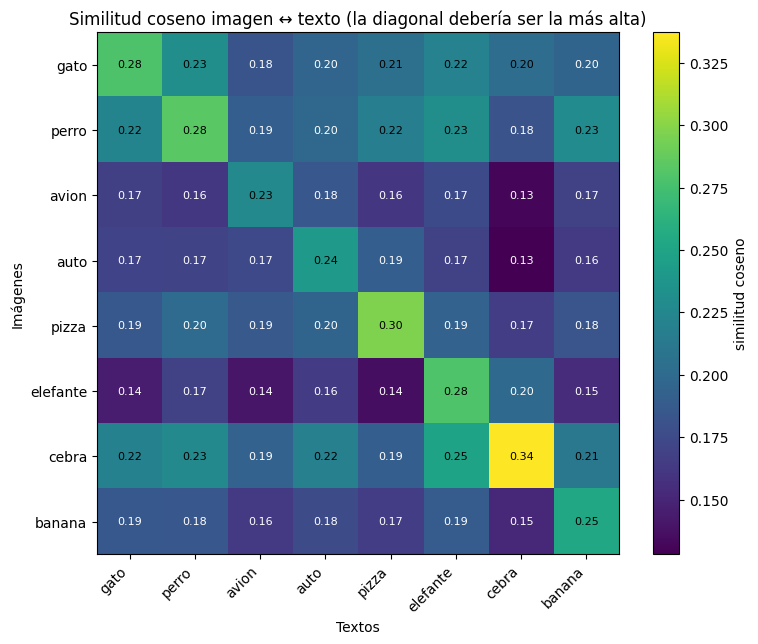

In [10]:
#  visualizar la matriz de similitud como mapa de calor
plt.figure(figsize=(8, 6.5))
plt.imshow(sims, cmap="viridis")
plt.colorbar(label="similitud coseno")
plt.xticks(range(len(captions)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)),  labels)
plt.xlabel("Textos"); plt.ylabel("Imágenes")
for i in range(len(labels)):
    for j in range(len(captions)):
        plt.text(j, i, f"{sims[i, j]:.2f}", ha="center", va="center",
                 color="white" if sims[i, j] < sims.max()*0.6 else "black", fontsize=8)
plt.title("Similitud coseno imagen ↔ texto (la diagonal debería ser la más alta)")
plt.tight_layout(); plt.show()

In [11]:

queries = [
    "a fluffy pet that barks",
    "a striped african animal",
    "italian food with melted cheese",
    "a fast red vehicle",
]
with torch.no_grad():
    q_inputs = processor(text=queries, return_tensors="pt", padding=True).to(device)
    q_embeds = model.get_text_features(**q_inputs).pooler_output
q_embeds = (q_embeds / q_embeds.norm(dim=-1, keepdim=True)).cpu().numpy()

q_sims = q_embeds @ image_embeds.T
print("CONSULTA LIBRE → IMAGEN")
for k, q in enumerate(queries):
    i = q_sims[k].argmax()
    print(f'  "{q}"  ->  {labels[i]}  (sim={q_sims[k, i]:.3f})')

CONSULTA LIBRE → IMAGEN
  "a fluffy pet that barks"  ->  perro  (sim=0.253)
  "a striped african animal"  ->  cebra  (sim=0.343)
  "italian food with melted cheese"  ->  pizza  (sim=0.241)
  "a fast red vehicle"  ->  auto  (sim=0.261)
